In [2]:
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import gc
import os


# 시각화 관련 설정
try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda:0") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)


# 로그
import logging

def init_logger() -> logging.Logger:
    logging.basicConfig(
        format="%(asctime)s [%(levelname)s] (%(filename)s:%(lineno)d) - %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
        level=logging.INFO,
        encoding="utf-8",
    )
    return logging.getLogger("")

logger = init_logger()

Matplotlib is building the font cache; this may take a moment.


In [3]:
import glob
from pycocotools.coco import COCO

BASE_JSON = COCO("./data/COCO_Football Pixel.json")

IMAGE_NAME_LIST = sorted(os.listdir("./data/images/"))
IMAGE_PATH_LIST = sorted(glob.glob(f"./data/images/*"))

loading annotations into memory...
Done (t=0.34s)
creating index...
index created!


In [4]:
IMAGE_PATH_LIST

['./data/images/Frame 1  (1).jpg',
 './data/images/Frame 1  (1).jpg___fuse.png',
 './data/images/Frame 1  (1).jpg___save.png',
 './data/images/Frame 1  (10).jpg',
 './data/images/Frame 1  (10).jpg___fuse.png',
 './data/images/Frame 1  (10).jpg___save.png',
 './data/images/Frame 1  (100).jpg',
 './data/images/Frame 1  (100).jpg___fuse.png',
 './data/images/Frame 1  (100).jpg___save.png',
 './data/images/Frame 1  (11).jpg',
 './data/images/Frame 1  (11).jpg___fuse.png',
 './data/images/Frame 1  (11).jpg___save.png',
 './data/images/Frame 1  (12).jpg',
 './data/images/Frame 1  (12).jpg___fuse.png',
 './data/images/Frame 1  (12).jpg___save.png',
 './data/images/Frame 1  (13).jpg',
 './data/images/Frame 1  (13).jpg___fuse.png',
 './data/images/Frame 1  (13).jpg___save.png',
 './data/images/Frame 1  (14).jpg',
 './data/images/Frame 1  (14).jpg___fuse.png',
 './data/images/Frame 1  (14).jpg___save.png',
 './data/images/Frame 1  (15).jpg',
 './data/images/Frame 1  (15).jpg___fuse.png',
 './dat

In [5]:
print("[누락 파일 점검]")

tmp_list, err_list = [], []

for name in IMAGE_NAME_LIST:
    tmp_list.append(int(name.split("(")[-1].split(")")[0]))

for i in range(100):
    tmp_count = tmp_list.count(i+1)
    if tmp_count != 3:
        err_list.append(i)

print(f"누락 파일: {err_list if len(err_list) != 0 else '0개'}")

[누락 파일 점검]
누락 파일: 0개


In [6]:
NORM_PATH_LIST = [x for x in IMAGE_PATH_LIST if x.endswith(".jpg")]
FUSE_PATH_LIST = [x for x in IMAGE_PATH_LIST if x.endswith("fuse.png")]
SAVE_PATH_LIST = [x for x in IMAGE_PATH_LIST if x.endswith("save.png")]

NORM_NAME_LIST = [x for x in IMAGE_NAME_LIST if x.endswith(".jpg")]
FUSE_NAME_LIST = [x for x in IMAGE_NAME_LIST if x.endswith("fuse.png")]
SAVE_NAME_LIST = [x for x in IMAGE_NAME_LIST if x.endswith("save.png")]

In [7]:
print(f"[사이즈 정보]")

import random
import torchvision

rand_idx = random.randint(1, len(NORM_PATH_LIST))

sample_norm_image = torchvision.io.read_image(NORM_PATH_LIST[rand_idx])
sample_fuse_image = torchvision.io.read_image(FUSE_PATH_LIST[rand_idx])
sample_save_image = torchvision.io.read_image(SAVE_PATH_LIST[rand_idx])

print(f"· 원본 이미지: {sample_norm_image.shape}")
print(f"· fuse 이미지: {sample_fuse_image.shape}")
print(f"· save 이미지: {sample_save_image.shape}")

[사이즈 정보]
· 원본 이미지: torch.Size([3, 1080, 1920])
· fuse 이미지: torch.Size([4, 1080, 1920])
· save 이미지: torch.Size([4, 1080, 1920])


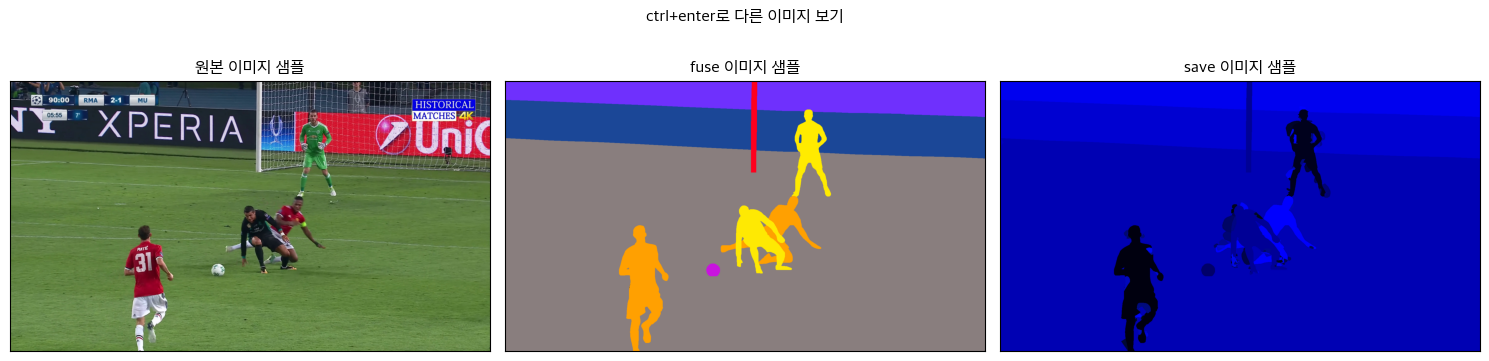

In [8]:
# 샘플 이미지 출력

# 축 숫자 표기 제거 함수 생성
def remove_ticks(columns=2):
    for num in range(columns):
        axes[num].set_xticks([])
        axes[num].set_yticks([])

rand_idx = random.randint(1, len(NORM_PATH_LIST))

sample_norm_image = torchvision.io.read_image(NORM_PATH_LIST[rand_idx]).permute(1, 2, 0)
sample_fuse_image = torchvision.io.read_image(FUSE_PATH_LIST[rand_idx])[:3, :, :].permute(1, 2, 0)
sample_save_image = torchvision.io.read_image(SAVE_PATH_LIST[rand_idx])[:3, :, :].permute(1, 2, 0)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(sample_norm_image)
axes[1].imshow(sample_fuse_image)
axes[2].imshow(sample_save_image)

remove_ticks(3)

fig.suptitle("ctrl+enter로 다른 이미지 보기")
axes[0].set_title("원본 이미지 샘플")
axes[1].set_title("fuse 이미지 샘플")
axes[2].set_title("save 이미지 샘플")

plt.tight_layout()
plt.show()

In [ ]:
print("[json 데이터]")

img_ids = BASE_JSON.getImgIds()

category_set = set()

for img_id in img_ids:
    ann_ids = BASE_JSON.getAnnIds(img_id)
    for ann_id in ann_ids:
        anns = BASE_JSON.loadAnns(ann_id)
        for ann in anns:
            category_set.add(ann["category_id"])

print(f"총 {len(category_set)} 종류: {category_set}")

print(f"\n[json 샘플 데이터]")

img_id = random.randint(1, len(BASE_JSON.getImgIds()))

ann_ids = BASE_JSON.getAnnIds(img_id)

for ann_id in ann_ids:
    anns = BASE_JSON.loadAnns(ann_id)
    for ann in anns:
        for key, value in ann.items():
            print(f"· {key}:  {value}")
        print("")

[json 데이터]
총 10 종류: {1392800, 1392801, 1392802, 1393250, 1392804, 1392805, 1392806, 1392807, 1392794, 1392799}

[json 샘플 데이터]
· id:  630
· image_id:  71
· segmentation:  [[1581, 1025, 1581, 1026, 1581, 1027, 1581, 1028, 1581, 1029, 1581, 1030, 1582, 1031, 1582, 1032, 1582, 1033, 1582, 1034, 1582, 1035, 1582, 1036, 1582, 1037, 1582, 1038, 1582, 1039, 1582, 1040, 1582, 1041, 1582, 1042, 1582, 1043, 1582, 1044, 1582, 1045, 1582, 1046, 1582, 1047, 1582, 1048, 1582, 1049, 1582, 1050, 1582, 1051, 1582, 1052, 1581, 1053, 1581, 1054, 1581, 1055, 1581, 1056, 1581, 1057, 1581, 1058, 1581, 1059, 1581, 1060, 1581, 1061, 1581, 1062, 1581, 1063, 1581, 1064, 1581, 1065, 1580, 1066, 1580, 1067, 1579, 1068, 1579, 1069, 1579, 1070, 1578, 1071, 1578, 1072, 1577, 1073, 1577, 1074, 1577, 1075, 1576, 1076, 1576, 1077, 1575, 1078, 1575, 1079, 1576, 1079, 1577, 1079, 1578, 1079, 1579, 1079, 1580, 1079, 1581, 1079, 1582, 1079, 1583, 1079, 1584, 1079, 1585, 1079, 1586, 1079, 1587, 1079, 1588, 1079, 1589, 1079, 

## 실험 설계

1. json 데이터로만 학습

2. save 이미지로 학습

3. fuse 이미지로 학습